# ASQA black-box RAGAS feature notebook

Notebook này tạo feature table theo từng sample từ `labeled_asqa.csv`, chỉ dùng các metric black-box của RAGAS khi **không có ground truth**, sau đó train một dãy classifier từ cơ bản đến mạnh hơn.

Output chính:
- `results/asqa_ragas_blackbox_features.csv`
- bảng so sánh các mô hình classifier
- model tốt nhất được lưu ra disk để dùng lại

## Imports and setup

In [71]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

import ast
import importlib
import importlib.util
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv
import os
sys.path.append('..')

import src.filtering.ragas as _ragas_mod
importlib.reload(_ragas_mod)

from src.filtering.ragas import RAGAS
from src.filtering.ragas_feature_extractor import RagasFeatureExtractor
from src.filtering.ragas_filter_trainer import RagasFilterTrainer
from src.filtering.ragas_filter import RagasFilter

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
HUGGINGFACE_API_KEY = os.getenv("HUGGINGFACE_API_KEY")
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")


XGBOOST_AVAILABLE = importlib.util.find_spec("xgboost") is not None
XGBClassifier = importlib.import_module("xgboost").XGBClassifier if XGBOOST_AVAILABLE else None

sys.path.append('..')


pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)
np.random.seed(42)

print(f"XGBOOST_AVAILABLE = {XGBOOST_AVAILABLE}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
XGBOOST_AVAILABLE = True


In [32]:
ASQA_PATH = Path('../data/asqa/labeled_asqa.csv')
OUTPUT_DIR = Path('../results')
OUTPUT_TRAIN_DIR = OUTPUT_DIR / "filter_training"
MODEL_DIR = Path('../models/ragas_filter')

## Imports data and initialize evaluator

In [33]:
df = pd.read_csv(ASQA_PATH)
df["label"] = df["label"].astype(int)

expected_columns = {"id", "question", "answer", "context", "label"}
missing_columns = expected_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing columns in CSV: {sorted(missing_columns)}")

print(df.shape)
display(df.head())
print(df["label"].value_counts(dropna=False).sort_index())

(8706, 5)


,id,question,context,answer,label
0,asqa_0,When does the new bunk'd come out?,"- (List of Bunk'd episodes) The new bunk'd episode 41 comes out on April 21, 2017, episode 42 comes out on April 28,...","The new bunk'd episode 41 comes out on April 21, 2017, episode 42 comes out on April 28, 2017 and episode 42 is due ...",1
1,asqa_1,Who won the 2016 ncaa football national championship?,- (2016 College Football Playoff National Championship) The 2015 - 2016 season's ncaa national football championship...,The 2015 - 2016 season's ncaa national football championship game was played between the Clemson Tigers and the Alab...,1
2,asqa_2,When was the last time the death penalty was used in pa?,"- (QA_1) As of 2017, when was the last time the death penalty was carried out in PA? July 6, 1999.\n- (QA_2) As of 2...","The last time the death penalty was used in pa was on July 6, 1999.",1
3,asqa_3,Where will failure of the left ventricle cause increased pressure?,"- (Heart failure) ""Backward"" failure of the left ventricle causes congestion of the lungs' blood vessels, and theref...","""Backward"" failure of the left ventricle causes congestion of the lungs' blood vessels, and therefore causes increas...",1
4,asqa_4,Who won the war between ethiopia and italy?,- (Second Italo-Ethiopian War) The first war between Italy and Ethiopia took place from 1895 to 1896. This war was w...,The first war between Italy and Ethiopia took place from 1895 to 1896. This war was won by the Ethiopian army after ...,1


label
0    4353
1    4353
Name: count, dtype: int64


## RAGAs feature extraction

In [34]:
# Black-box RAGAS metrics: no ground-truth dependent scores
# We intentionally skip answer_correctness / answer_similarity.
metric_names = [
    "faithfulness",
    "answer_relevancy",
    "context_relevancy",
]

evaluator = RAGAS(
    metrics=metric_names,

    # OpenAI models
    llm_model="gpt-4o-mini",
    embedding_model="text-embedding-3-small",

    # optional
    api_key=OPENAI_API_KEY,

    # optional
    temperature=0,
)


extractor = RagasFeatureExtractor(ragas_evaluator=evaluator, feature_cols=metric_names)
feature_df = extractor.transform(data=df, 
                                feature_path=OUTPUT_TRAIN_DIR / "asqa_ragas_features.csv",
                                checkpoint_path=OUTPUT_TRAIN_DIR / "asqa_ragas_checkpoints.csv")
print(f"Save RAGAS features to {OUTPUT_TRAIN_DIR / 'asqa_ragas_features.csv'}")
print(feature_df.shape)
display(feature_df.describe().T)
display(feature_df.head())

Resuming from sample 8706
Save RAGAS features to ..\results\filter_training\asqa_ragas_features.csv
(8706, 5)


,count,mean,std,min,25%,50%,75%,max
label,8706.0,0.500000,0.500029,0.0,0.000000,0.500000,1.000000,1.0
faithfulness,8706.0,0.698412,0.327578,0.0,0.500000,0.800000,1.000000,1.0
answer_relevancy,8706.0,0.737265,0.208051,0.0,0.675609,0.790222,0.870178,1.0
context_relevancy,8706.0,0.170983,0.123773,0.0,0.090909,0.125000,0.222222,1.0


,id,label,faithfulness,answer_relevancy,context_relevancy
0,asqa_0,1,0.666667,0.726235,0.090909
1,asqa_1,1,1.000000,0.957490,0.111111
2,asqa_2,1,1.000000,0.965820,0.111111
3,asqa_3,1,1.000000,0.641608,0.125000
4,asqa_4,1,1.000000,0.800938,0.214286


## Filter Models Training

Load features and labels

In [35]:
feature_df = pd.read_csv(OUTPUT_TRAIN_DIR / "asqa_ragas_features.csv")
print(feature_df.shape)

(8706, 5)


Data splitting

In [36]:
feature_cols = [col for col in feature_df.columns if col not in {"id", "label"}]
X = feature_df[feature_cols].copy()
y = feature_df["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

Model training:
- Logistic Regression
- Random Forest
- Gradient Boosting
- HistGradient Boosting
- Extra Trees
- XGBoost *(if available)*


In [37]:
models = {
    "logistic_regression": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
        ]
    ),
    "random_forest": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=400,
                max_depth=None,
                random_state=42,
                class_weight="balanced_subsample",
                n_jobs=-1,
            )),
        ]
    ),
    "gradient_boosting": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingClassifier(random_state=42)),
        ]
    ),
    "hist_gradient_boosting": HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=300,
        max_leaf_nodes=31,
        random_state=42,
    ),
    "extra_trees": Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesClassifier(
                n_estimators=500,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1,
            )),
        ]
    ),
}

if XGBOOST_AVAILABLE:
    models["xgboost"] = XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1,
        missing=np.nan,
    )

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Features: {feature_cols}")
print(f"Models: {list(models.keys())}")

Train size: 6964 | Test size: 1742
Features: ['faithfulness', 'answer_relevancy', 'context_relevancy']
Models: ['logistic_regression', 'random_forest', 'gradient_boosting', 'hist_gradient_boosting', 'extra_trees', 'xgboost']


Evaluate and compare models, save results to CSV

In [38]:
def evaluate_classifier(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    metrics = {
        "accuracy": accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0),
    }

    if hasattr(model, "predict_proba"):
        try:
            probabilities = model.predict_proba(X_test)[:, 1]
            metrics["roc_auc"] = roc_auc_score(y_test, probabilities)
        except Exception:
            metrics["roc_auc"] = np.nan
    else:
        metrics["roc_auc"] = np.nan

    return metrics, predictions


results = []
trained_models = {}

for name, model in models.items():
    metrics, _ = evaluate_classifier(model, X_train, X_test, y_train, y_test)
    results.append({"model": name, **metrics})
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(["f1", "accuracy"], ascending=False).reset_index(drop=True)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
print(f"Best model: {best_model_name}")

,model,accuracy,precision,recall,f1,roc_auc
0,gradient_boosting,0.900115,0.922424,0.873708,0.897406,0.961624
1,xgboost,0.890356,0.913625,0.862227,0.887183,0.960556
2,hist_gradient_boosting,0.877727,0.888889,0.863375,0.875946,0.953798
3,random_forest,0.872560,0.884935,0.856487,0.870478,0.946578
4,extra_trees,0.870838,0.888221,0.848450,0.867880,0.922074
5,logistic_regression,0.787600,0.764520,0.831228,0.796480,0.883097


Best model: gradient_boosting


In [ ]:
import joblib

MODEL_DIR.mkdir(parents=True, exist_ok=True)
best_model_path = MODEL_DIR / f"{best_model_name}.joblib"
joblib.dump(best_model, best_model_path)

print(f"Saved best model to: {best_model_path}")

final_predictions = best_model.predict(X_test)
print(classification_report(y_test, final_predictions, zero_division=0))

Saved best model to: ..\models\ragas_filter\gradient_boosting.joblib
              precision    recall  f1-score   support

           0       0.88      0.93      0.90       871
           1       0.92      0.87      0.90       871

    accuracy                           0.90      1742
   macro avg       0.90      0.90      0.90      1742
weighted avg       0.90      0.90      0.90      1742



Best model: Gradient Boosting Classifier.

Try to find feature importance from the best model.

In [40]:
def unwrap_estimator(model):
    if hasattr(model, "named_steps"):
        # lấy step cuối trong Pipeline
        return list(model.named_steps.values())[-1]
    return model


def get_feature_importance(model, feature_cols):
    clf = unwrap_estimator(model)

    if not hasattr(clf, "feature_importances_"):
        raise ValueError(f"{type(clf)} không có feature_importances_")

    importance_df = (
        pd.DataFrame({
            "feature": feature_cols,
            "importance": clf.feature_importances_,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    importance_df["importance_pct"] = (
        importance_df["importance"] / importance_df["importance"].sum()
    )

    return importance_df

In [41]:
# load model from disk
# get model from the only .joblib file in the model directory
model_files = list(MODEL_DIR.glob("*.joblib"))

best_model = joblib.load(model_files[0])
importance_df = get_feature_importance(best_model, feature_cols)
display(importance_df)

,feature,importance,importance_pct
0,faithfulness,0.890460,0.890460
1,context_relevancy,0.099246,0.099246
2,answer_relevancy,0.010294,0.010294


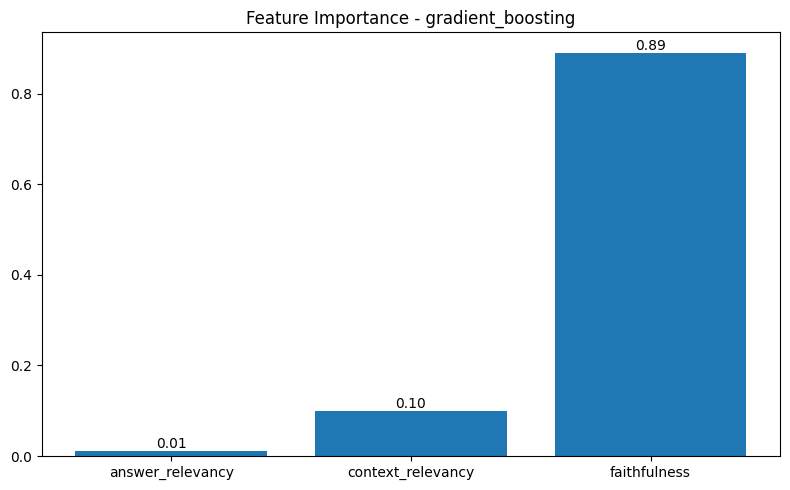

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(
    importance_df["feature"][::-1],
    importance_df["importance"][::-1],
)
importances = importance_df["importance"].values
for i, (feature, importance) in enumerate(zip(importance_df["feature"][::-1], importance_df["importance"][::-1])):
    plt.text(i, importance, f"{importance:.2f}", ha="center", va="bottom")
plt.title(f"Feature Importance - {best_model_name}")
plt.tight_layout()
plt.show()

## Test on other datasets (optional)

In [43]:
MS_PATH = Path('../data/ms-macro/labeled_msmacro.csv')
WIKI_PATH = Path('../data/wikiEval/labeled_wikieval.csv')
OUTPUT_FILTER = OUTPUT_DIR / "filter_inference"

In [57]:
metric_names = [
    "faithfulness",
    "answer_relevancy",
    "context_relevancy",
]

evaluator = RAGAS(
    metrics=metric_names,

    # OpenAI models
    llm_model="gpt-4o-mini",
    embedding_model="text-embedding-3-small",

    # optional
    api_key=OPENAI_API_KEY,

    # optional
    temperature=0,
)


extractor = RagasFeatureExtractor(ragas_evaluator=evaluator, feature_cols=metric_names)

ragas_filter = RagasFilter(model_path=best_model_path, feature_extractor=extractor, output_dir=OUTPUT_FILTER)

In [74]:
def plot_evaluation_results(evaluation, data_name):
    if "classification" in evaluation:
        
        metrics = evaluation["classification"]

        print(f"\nClassification Metrics for {data_name}:")
        for key, value in metrics.items():
            if key in {"accuracy", "precision", "recall", "f1", "roc_auc"}:
                print(f"  {key}: {value}")


        cm = np.array(metrics["confusion_matrix"])

        plt.figure(figsize=(4,3))

        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Rejected", "Accepted"],
            yticklabels=["Rejected", "Accepted"],
        )

        plt.xlabel("Predicted")
        plt.ylabel("Ground Truth")
        plt.title("Confusion Matrix")

        plt.show()

        report_df = pd.DataFrame(metrics["classification_report"]).transpose()
        display(report_df.round(4))

    if "quality" in evaluation:
        quality_df = evaluation["quality"]
        print(f"\nAnswer Quality Scores for {data_name}:")
        display(quality_df.describe().T)

### MS Marco dataset
Use 500 longest answers from MS Marco, synthesize to 1000 sample with hallucination.
Use RAGAS features, and apply the best model to predict labels.

In [76]:
ms_marco_df = pd.read_csv(MS_PATH)
print(ms_marco_df.shape)
display(ms_marco_df.head())

(1000, 5)


,id,question,context,answer,label
0,10736,buying a car dealer vs. private seller,[P1] Source: http://www.consumerhelp.ie/buying-car-dealer-private\nBuying a car-dealer or private seller. There are ...,Traders are often called “dealers” and sell cars as part of their business.Private sellers generally have only one c...,1
1,12719,convert dollar pay into salary to twice a month,[P1] Source: http://www.ehow.com/how_12044390_convert-annual-salary-being-paid-twice-month.html\nInstructions. Deter...,"Determine what your paydays will be throughout the year. Often, employees who receive bimonthly paychecks have payda...",1
2,17806,how to plant dwarf apple trees,[P1] Source: http://www.gardenguides.com/79766-plant-dwarf-apple-trees.html\nStep 1. Locate a site for the dwarf app...,Locate a site for the dwarf apple tree where it will get at least six hours or more of full sun during the day. The ...,1
3,14675,what arthritis is,[P1] Source: http://www.healthline.com/health/arthritis\nArthritis is inflammation of the joints (the points where b...,Arthritis is inflammation of the joints (the points where bones meet) in one or more areas of the body.Arthritis is ...,1
4,16014,how to record audio with iphone,[P1] Source: http://www.solveyourtech.com/record-audio-iphone-5/\nYou can learn how to record audio on an iPhone usi...,"1: Open the Voice Memos app. If you cannot find it it might be in a Utilities folder, as in the screenshot below. Yo...",1


Feature extraction using RAGAS Evaluator.

In [47]:
ms_feature_df = extractor.transform(data=ms_marco_df, 
                                    feature_path=OUTPUT_FILTER/"msmarco_ragas_features.csv",
                                    checkpoint_path=OUTPUT_FILTER/"msmarco_ragas_checkpoints.csv")
print(f"Save RAGAS features to {OUTPUT_FILTER/'msmarco_ragas_features.csv'}")
print(ms_feature_df.shape)
display(ms_feature_df.head())
display(ms_feature_df.describe().T)

Resuming from sample 1000
Save RAGAS features to ..\results\filter_inference\msmarco_ragas_features.csv
(1000, 5)


,id,label,faithfulness,answer_relevancy,context_relevancy
0,10736,1,1.0,0.763581,0.857143
1,12719,1,1.0,0.609449,0.875000
2,17806,1,1.0,0.871016,1.000000
3,14675,1,1.0,0.697597,0.636364
4,16014,1,1.0,0.766354,0.666667


,count,mean,std,min,25%,50%,75%,max
label,1000.0,0.500000,0.500250,0.0,0.000000,0.500000,1.000000,1.0
faithfulness,1000.0,0.534171,0.449368,0.0,0.089015,0.500000,1.000000,1.0
answer_relevancy,1000.0,0.697043,0.214969,0.0,0.619082,0.747646,0.846537,1.0
context_relevancy,1000.0,0.497798,0.289702,0.0,0.250000,0.480769,0.750000,1.0


Run inference model, evaluate results, and save to CSV.


Classification Metrics for MS MARCO:
  accuracy: 0.91
  precision: 0.9035433070866141
  recall: 0.918
  f1: 0.9107142857142857
  roc_auc: 0.971422


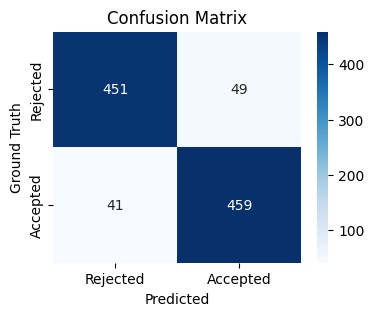

,precision,recall,f1-score,support
0,0.9167,0.902,0.9093,500.00
1,0.9035,0.918,0.9107,500.00
accuracy,0.9100,0.910,0.9100,0.91
macro avg,0.9101,0.910,0.9100,1000.00
weighted avg,0.9101,0.910,0.9100,1000.00


In [75]:
msmacro_filter= ragas_filter.run(data=ms_marco_df, feature_df=ms_feature_df,
                                                    filter_path=OUTPUT_FILTER/"msmarco_filtered.csv",
                                                    data_name="msmarco", eval_mode="classification")

plot_evaluation_results(msmacro_filter["evaluation"], "MS MARCO")

### WikiEval dataset
Use full WikiEval dataset, synthesize hallucination samples. 

In [77]:
wikieval_df = pd.read_csv(WIKI_PATH)
print(wikieval_df.shape)
display(wikieval_df.head())

(100, 5)


,id,question,context,answer,label
0,0_pos,"When is the scheduled launch date and time for the PSLV-C56 mission, and where will it be launched from?",The PSLV-C56 is the 58th mission of Indian Space Research Organisation's Polar Satellite Launch Vehicle (PSLV) and t...,"The PSLV-C56 mission is scheduled to be launched on Sunday, 30 July 2023 at 06:30 IST / 01:00 UTC. It will be launch...",1
1,0_neg,"When is the scheduled launch date and time for the PSLV-C56 mission, and where will it be launched from?",The PSLV-C56 is the 58th mission of Indian Space Research Organisation's Polar Satellite Launch Vehicle (PSLV) and t...,The scheduled launch date and time for the PSLV-C56 mission have not been provided.The PSLV-C56 mission is an import...,0
2,1_pos,What is the objective of the Uzbekistan-Afghanistan-Pakistan Railway Project and how is it expected to enhance trade...,The Uzbekistan–Afghanistan–Pakistan Railway Project is an extensive project undertaking with the objective of creati...,The objective of the Uzbekistan-Afghanistan-Pakistan Railway Project is to create a direct railway link between Uzbe...,1
3,1_neg,What is the objective of the Uzbekistan-Afghanistan-Pakistan Railway Project and how is it expected to enhance trade...,The Uzbekistan–Afghanistan–Pakistan Railway Project is an extensive project undertaking with the objective of creati...,The objective of the Uzbekistan-Afghanistan-Pakistan Railway Project is to establish a railway network connecting th...,0
4,2_pos,When was PharmaCann founded and what is its headquarters location?,"Found in 2014 by Theodore Scott, PharmaCann is an American cannabis company headquartered in the state of Illinois, ...",PharmaCann was founded in 2014 by Theodore Scott. Its headquarters is located in the state of Illinois.,1


Ragas feature extraction

In [78]:
wikieval_feature_df = extractor.transform(data=wikieval_df,
                                        feature_path=OUTPUT_FILTER/"wikieval_ragas_features.csv",
                                        checkpoint_path=OUTPUT_FILTER/"wikieval_ragas_checkpoints.csv")
print(f"Save RAGAS features to {OUTPUT_FILTER/'wikieval_ragas_features.csv'}")
print(wikieval_feature_df.shape)
display(wikieval_feature_df.head())
display(wikieval_feature_df.describe().T)

Evaluating: 100%|██████████| 150/150 [01:16<00:00,  1.95it/s]


Saved checkpoint: 50/100


Evaluating: 100%|██████████| 150/150 [01:16<00:00,  1.95it/s]


Saved checkpoint: 100/100
Save RAGAS features to ..\results\filter_inference\wikieval_ragas_features.csv
(100, 5)


,id,label,faithfulness,answer_relevancy,context_relevancy
0,0_pos,1,1.000000,0.916225,0.250000
1,0_neg,0,0.500000,0.000000,0.250000
2,1_pos,1,1.000000,0.872695,0.666667
3,1_neg,0,0.666667,0.872695,0.666667
4,2_pos,1,1.000000,0.988983,0.500000


,count,mean,std,min,25%,50%,75%,max
label,100.0,0.500000,0.502519,0.000000,0.000000,0.500000,1.000000,1.0
faithfulness,100.0,0.700448,0.353197,0.000000,0.383333,0.910714,1.000000,1.0
answer_relevancy,100.0,0.672493,0.384992,0.000000,0.661520,0.870860,0.921378,1.0
context_relevancy,100.0,0.222846,0.189309,0.015873,0.094866,0.178375,0.277778,1.0


Run inference model, evaluate results, and save to CSV.


Classification Metrics for WikiEval:
  accuracy: 0.9
  precision: 0.9
  recall: 0.9
  f1: 0.9
  roc_auc: 0.9532


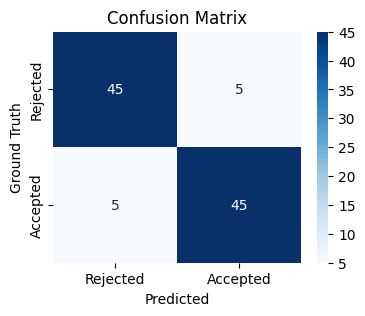

,precision,recall,f1-score,support
0,0.9,0.9,0.9,50.0
1,0.9,0.9,0.9,50.0
accuracy,0.9,0.9,0.9,0.9
macro avg,0.9,0.9,0.9,100.0
weighted avg,0.9,0.9,0.9,100.0


In [79]:
wikieval_filter = ragas_filter.run(data=wikieval_df, feature_df=wikieval_feature_df,
                                                    filter_path=OUTPUT_FILTER/"wikieval_filtered.csv", 
                                                    data_name="wikieval", eval_mode="classification")
plot_evaluation_results(wikieval_filter["evaluation"], "WikiEval")